In [1]:
import pandas as pd
import numpy as np

# -----------------------------
# File paths
# -----------------------------
files = {
    "2020": r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_Qn-1\2020.txt",
    "2021": r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_Qn-1\2021.txt",
    "2022": r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_Qn-1\2022.txt",
    "2023": r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_Qn-1\2023.txt",
    "2024": r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-5\wave_data_Qn-1\2024.txt",
}

# -----------------------------
# Store all cleaned WVHT data
# -----------------------------
all_data = []

# -----------------------------
# Loop through files
# -----------------------------
for year, path in files.items():
    # Read file (skip 2nd row = units row)
    df = pd.read_csv(
        path,
        delim_whitespace=True,
        skiprows=[1],   # skip units row
        engine='python'
    )

    # Extract WVHT column
    if "WVHT" not in df.columns:
        print(f"WVHT column not found in {year}")
        continue

    wvht = pd.to_numeric(df["WVHT"], errors="coerce")

    # Remove invalid values
    wvht_clean = wvht[
        (wvht.notna()) &      # remove NaN
        (wvht != 99.0)        # remove bad values
    ]

    # Save for 5-year analysis
    all_data.append(wvht_clean)

    # Compute stats
    mean_val = wvht_clean.mean()
    std_val = wvht_clean.std()

    print(f"\nYear: {year}")
    print(f"Mean Hs = {mean_val:.3f} m")
    print(f"Std Dev = {std_val:.3f} m")

# -----------------------------
# Combine all years
# -----------------------------
all_data_combined = pd.concat(all_data)

mean_all = all_data_combined.mean()
std_all = all_data_combined.std()

print("\n==============================")
print("5-Year Combined Statistics")
print("==============================")
print(f"Mean Hs = {mean_all:.3f} m")
print(f"Std Dev = {std_all:.3f} m")

# -----------------------------
# Closure depth (optional)
# -----------------------------
hc_all = 2 * mean_all + 11 * std_all

print("\nClosure Depth (5-year):")
print(f"hc = {hc_all:.3f} m")

C:\Users\sahad2\AppData\Local\Temp\ipykernel_9812\4061212746.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(



Year: 2020
Mean Hs = 1.514 m
Std Dev = 0.574 m


C:\Users\sahad2\AppData\Local\Temp\ipykernel_9812\4061212746.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(



Year: 2021
Mean Hs = 1.635 m
Std Dev = 0.647 m


C:\Users\sahad2\AppData\Local\Temp\ipykernel_9812\4061212746.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(



Year: 2022
Mean Hs = 1.490 m
Std Dev = 0.579 m


C:\Users\sahad2\AppData\Local\Temp\ipykernel_9812\4061212746.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(



Year: 2023
Mean Hs = 1.674 m
Std Dev = 0.742 m


C:\Users\sahad2\AppData\Local\Temp\ipykernel_9812\4061212746.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(



Year: 2024
Mean Hs = 1.660 m
Std Dev = 0.743 m

5-Year Combined Statistics
Mean Hs = 1.595 m
Std Dev = 0.665 m

Closure Depth (5-year):
hc = 10.501 m


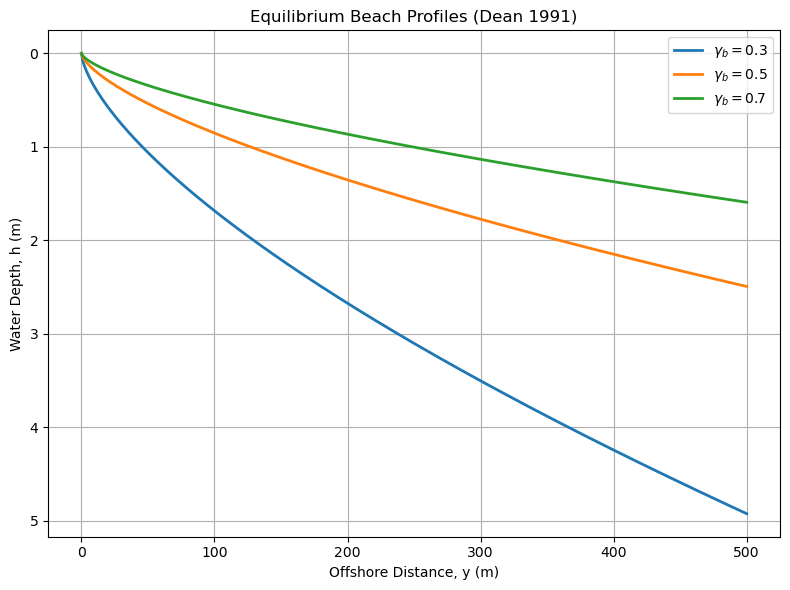

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Define offshore distance (y)
# -----------------------------
y = np.linspace(0, 500, 500)   # 0 to 500 m

# -----------------------------
# Define A values
# -----------------------------
A1 = 0.0782   # gamma_b = 0.3
A2 = 0.0396   # gamma_b = 0.5
A3 = 0.0253  # gamma_b = 0.7

# -----------------------------
# Compute profiles
# -----------------------------
h1 = A1 * y**(2/3)
h2 = A2 * y**(2/3)
h3 = A3 * y**(2/3)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,6))

plt.plot(y, h1, label=r'$\gamma_b = 0.3$', linewidth=2)
plt.plot(y, h2, label=r'$\gamma_b = 0.5$', linewidth=2)
plt.plot(y, h3, label=r'$\gamma_b = 0.7$', linewidth=2)

# Labels and title
plt.xlabel("Offshore Distance, y (m)")
plt.ylabel("Water Depth, h (m)")
plt.title("Equilibrium Beach Profiles (Dean 1991)")

# Grid and legend
plt.grid(True)
plt.legend()

# Invert y-axis (optional but standard for beach profiles)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

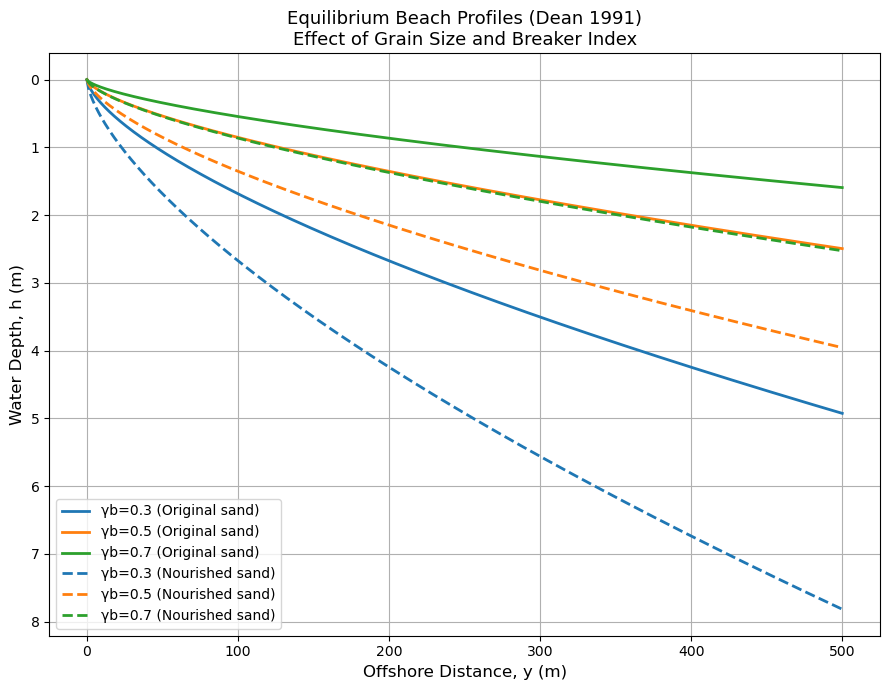

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Offshore distance (m)
# -----------------------------
y = np.linspace(0, 500, 500)

# -----------------------------
# Part (b): Original sand (0.5 mm)
# -----------------------------
A_orig = {
    0.3: 0.0782,
    0.5: 0.0396,
    0.7: 0.0253
}

# -----------------------------
# Part (c): Nourished sand (1.0 mm)
# -----------------------------
A_new = {
    0.3: 0.1241,
    0.5: 0.0628,
    0.7: 0.0401

}

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(9,7))

# Colors for consistency
colors = {
    0.3: 'tab:blue',
    0.5: 'tab:orange',
    0.7: 'tab:green'
}

# Plot original profiles (solid)
for gamma, A in A_orig.items():
    h = A * y**(2/3)
    plt.plot(y, h, color=colors[gamma], linewidth=2,
             label=f'γb={gamma} (Original sand)')

# Plot nourished profiles (dashed)
for gamma, A in A_new.items():
    h = A * y**(2/3)
    plt.plot(y, h, '--', color=colors[gamma], linewidth=2,
             label=f'γb={gamma} (Nourished sand)')

# -----------------------------
# Labels and formatting
# -----------------------------
plt.xlabel("Offshore Distance, y (m)", fontsize=12)
plt.ylabel("Water Depth, h (m)", fontsize=12)
plt.title("Equilibrium Beach Profiles (Dean 1991)\nEffect of Grain Size and Breaker Index", fontsize=13)

plt.grid(True)
plt.legend()

# Invert depth axis (important for coastal plots)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()